Original shape: (435352, 13)

Prepared shape: (422818, 134)

Target counts:
Delay
0    335322
1     87496
Name: count, dtype: int64

Target proportions:
Delay
0    0.793
1    0.207
Name: proportion, dtype: float64

Best Parameters
Logistic Regression: {'max_iter': 1000, 'class_weight': 'balanced', 'C': 0.1}
Random Forest: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 15, 'class_weight': 'balanced'}
XGBoost: {'subsample': 0.8, 'scale_pos_weight': np.float64(3.832407103161564), 'n_estimators': 150, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

MODEL EVALUATION SUMMARY
                 Model  Accuracy  Precision  Recall  F1-score  ROC_AUC  \
0              XGBoost     0.642      0.311   0.598     0.409    0.671   
1        Random Forest     0.644      0.310   0.590     0.407    0.670   
2  Logistic Regression     0.619      0.297   0.614     0.400    0.659   

   PR_AUC  BrierScore  LogLoss  
0   0.344       0.227    0.645  
1   0.343

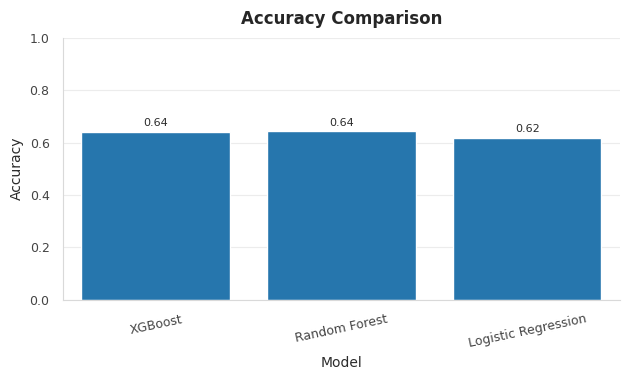

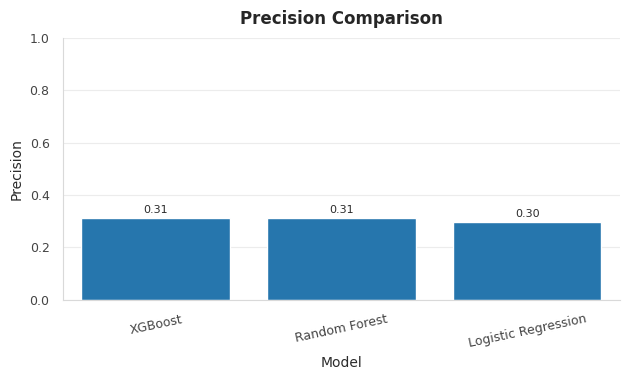

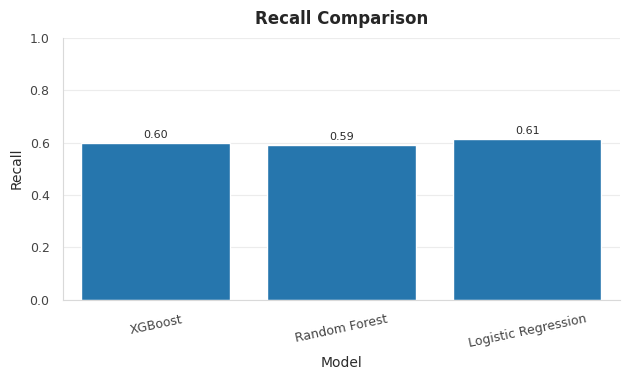

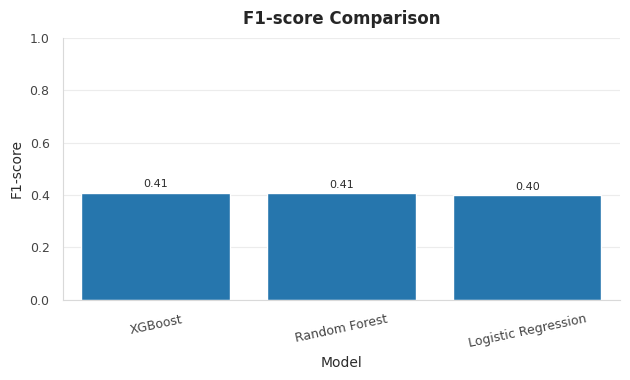

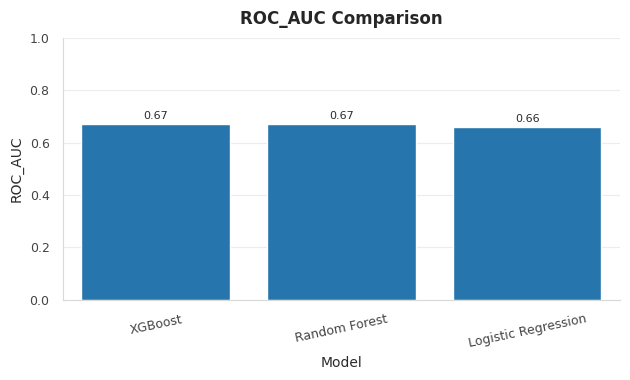

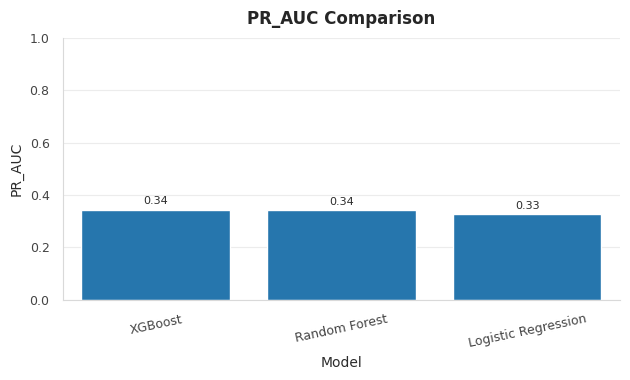

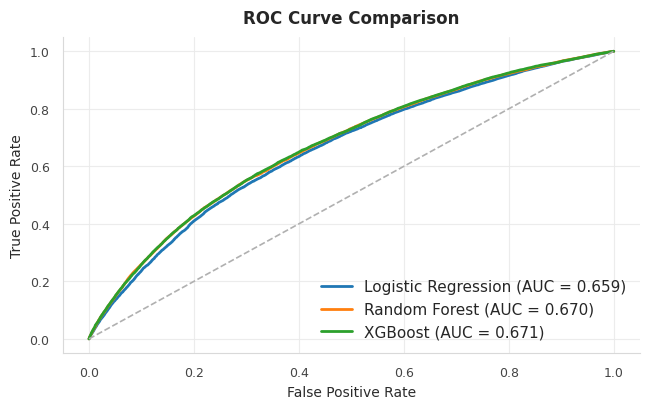

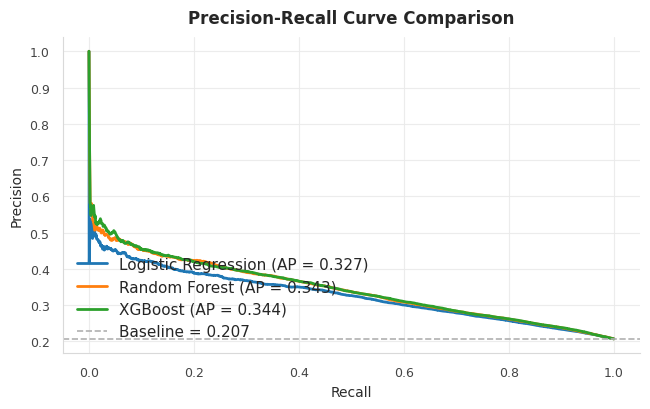

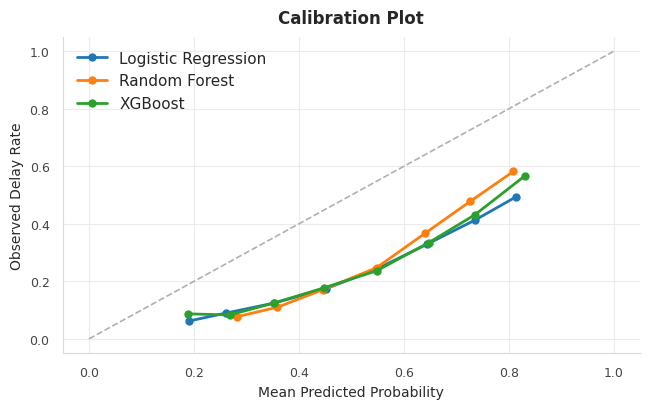


PROBABILITY-FORECASTING METRICS
                 Model  BrierScore  LogLoss
0              XGBoost      0.2265   0.6450
1        Random Forest      0.2273   0.6468
2  Logistic Regression      0.2305   0.6532

Best model by ROC-AUC: XGBoost
Best model by Brier Score: XGBoost

THRESHOLD ANALYSIS FOR: XGBoost
   Threshold  Accuracy  Precision  Recall  F1-score     TN     FP     FN  \
0        0.3     0.307      0.224   0.952     0.362   9306  57759    845   
1        0.5     0.642      0.311   0.598     0.409  43820  23245   7031   
2        0.7     0.785      0.437   0.144     0.217  63815   3250  14973   

      TP  
0  16654  
1  10468  
2   2526  


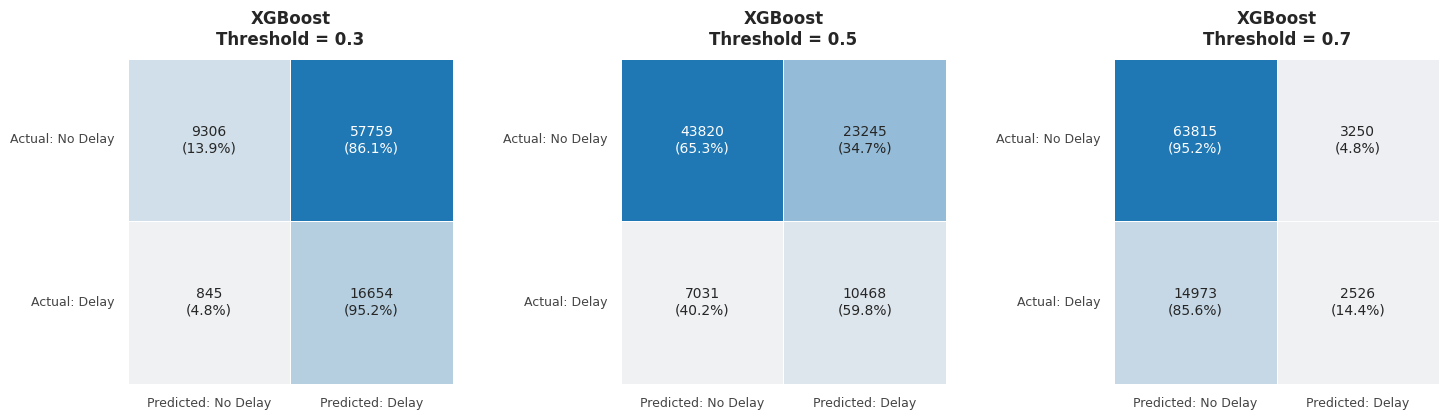

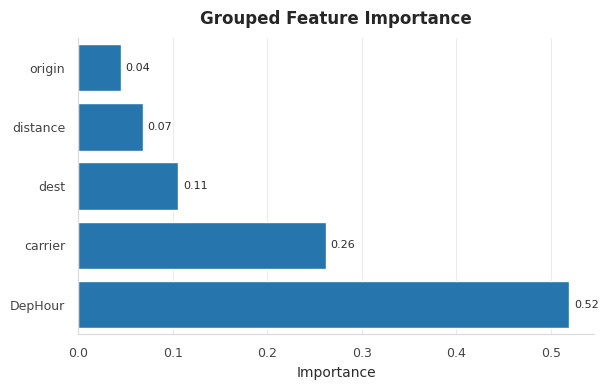


Grouped Feature Importance
origin      0.045
distance    0.068
dest        0.106
carrier     0.262
DepHour     0.519
dtype: float64


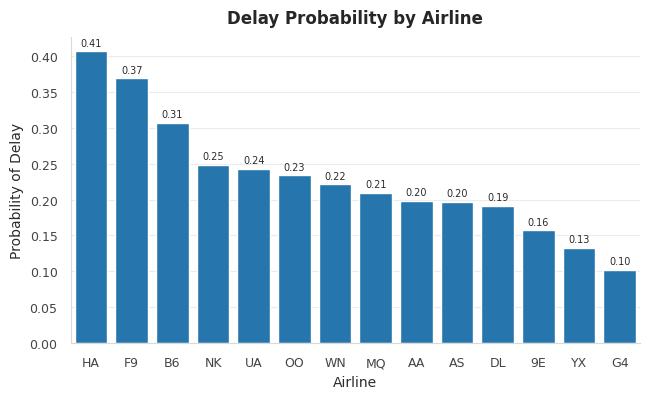

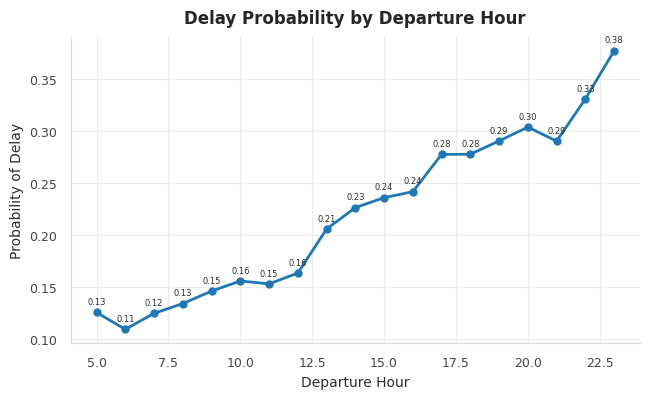

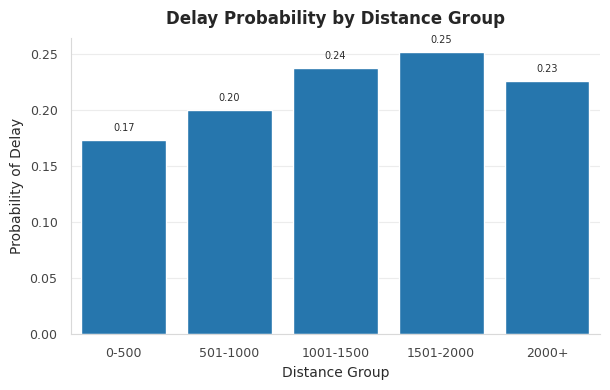

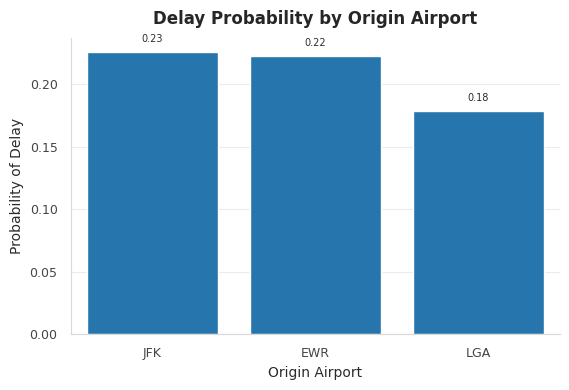


Delay Probability by Airline
carrier
HA    0.406
F9    0.369
B6    0.307
NK    0.249
UA    0.243
OO    0.234
WN    0.221
MQ    0.209
AA    0.198
AS    0.197
DL    0.192
9E    0.157
YX    0.132
G4    0.102
Name: Delay, dtype: float64

Delay Probability by Departure Hour
DepHour
5     0.126
6     0.109
7     0.125
8     0.134
9     0.146
10    0.156
11    0.153
12    0.164
13    0.206
14    0.227
15    0.236
16    0.242
17    0.278
18    0.278
19    0.291
20    0.304
21    0.290
22    0.331
23    0.377
Name: Delay, dtype: float64

Delay Probability by Distance Group
DistanceGroup
0-500        0.173
501-1000     0.200
1001-1500    0.237
1501-2000    0.251
2000+        0.226
Name: Delay, dtype: float64

Delay Probability by Origin Airport
origin
JFK    0.226
EWR    0.222
LGA    0.179
Name: Delay, dtype: float64

FINAL MODEL INTERPRETATION
- Strongest ranking model (ROC-AUC): XGBoost
- Best probability calibration (lowest Brier score): XGBoost
- XGBoost performs best on both discrimination

In [ ]:
# FLIGHT DELAY PREDICTION

# 1. IMPORTS AND SETUP
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    brier_score_loss, log_loss, average_precision_score,
    precision_recall_curve
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb


# VISUALISATION SETTINGS
sns.set_theme(style="whitegrid", context="notebook")

BAR_COLOR = "#1f77b4"
LINE_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c"]
CMAP_SOFT = sns.light_palette("#1f77b4", as_cmap=True)

plt.rcParams.update({
    "figure.figsize": (6.8, 4.2),
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "semibold",
    "axes.labelsize": 10,
    "axes.labelcolor": "#2B2B2B",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "xtick.color": "#444444",
    "ytick.color": "#444444",
    "axes.edgecolor": "#D9D9D9",
    "axes.linewidth": 0.8,
    "grid.color": "#EAEAEA",
    "grid.linewidth": 0.8,
    "grid.alpha": 0.9,
    "legend.frameon": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

def polish_axes(ax, grid_axis="y"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#D9D9D9")
    ax.spines["bottom"].set_color("#D9D9D9")
    ax.tick_params(colors="#444444")
    ax.grid(axis=grid_axis, color="#EAEAEA", linewidth=0.8)
    return ax


# 2. LOAD DATA
df = pd.read_csv("Flights1.csv")
print("Original shape:", df.shape)


# 3. DATA PREPARATION
df = df.dropna().copy()

# Binary target: delayed if arrival delay > 15 minutes
df["Delay"] = np.where(df["arr_delay"] > 15, 1, 0)

# Extract scheduled departure hour
df["DepHour"] = df["sched_dep_time"] // 100

# Feature selection
features = ["carrier", "DepHour", "distance"]
if "origin" in df.columns:
    features.append("origin")
if "dest" in df.columns:
    features.append("dest")

X = df[features].copy()
y = df["Delay"]

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

print("\nPrepared shape:", X.shape)
print("\nTarget counts:")
print(y.value_counts().sort_index())
print("\nTarget proportions:")
print(y.value_counts(normalize=True).sort_index().round(3))

# Handle any remaining NaN values in features
original_indices = X.index
X = X.dropna()
y = y.loc[X.index]

if len(X) < len(original_indices):
    print(f"\nDropped {len(original_indices) - len(X)} rows due to missing feature values.")
    print("Updated shape:", X.shape)


# 4. TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Scaling Logistic Regression
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 5. CROSS-VALIDATION SETUP
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


# 6. HYPERPARAMETER TUNING

# Logistic Regression
lr = LogisticRegression()
lr_params = {
    "C": [0.1, 1, 10],
    "class_weight": [None, "balanced"],
    "max_iter": [1000]
}

lr_search = RandomizedSearchCV(
    estimator=lr,
    param_distributions=lr_params,
    n_iter=4,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=42
)
lr_search.fit(X_train_scaled, y_train)
best_lr = lr_search.best_estimator_

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf_params = {
    "n_estimators": [100, 150, 200],
    "max_depth": [8, 10, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "class_weight": [None, "balanced", "balanced_subsample"]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=5,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=42
)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

# XGBoost
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

xgb_clf = xgb.XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

xgb_params = {
    "n_estimators": [100, 150, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "scale_pos_weight": [1, scale_pos_weight]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=xgb_params,
    n_iter=3,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=42
)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

print("\nBest Parameters")
print("Logistic Regression:", lr_search.best_params_)
print("Random Forest:", rf_search.best_params_)
print("XGBoost:", xgb_search.best_params_)


# 7. MODEL EVALUATION SETUP
models = {
    "Logistic Regression": (best_lr, X_test_scaled),
    "Random Forest": (best_rf, X_test),
    "XGBoost": (best_xgb, X_test)
}

pred_store = {}

for name, (model, X_input) in models.items():
    y_prob = model.predict_proba(X_input)[:, 1]
    pred_store[name] = y_prob


# 8. EVALUATION SUMMARY TABLE
summary_rows = []

for name, y_prob in pred_store.items():
    y_pred_05 = (y_prob >= 0.5).astype(int)

    summary_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred_05),
        "Precision": precision_score(y_test, y_pred_05, zero_division=0),
        "Recall": recall_score(y_test, y_pred_05, zero_division=0),
        "F1-score": f1_score(y_test, y_pred_05, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "PR_AUC": average_precision_score(y_test, y_prob),
        "BrierScore": brier_score_loss(y_test, y_prob),
        "LogLoss": log_loss(y_test, y_prob)
    })

results_df = pd.DataFrame(summary_rows)
results_df = results_df.sort_values("ROC_AUC", ascending=False).reset_index(drop=True)

print("\nMODEL EVALUATION SUMMARY")
print(results_df.round(3))


# 9. CLASSIFICATION REPORTS AT THRESHOLD 0.5
print("\nNOTE:")
print("The following classification reports are shown at threshold = 0.5.")
print("However, because the models produce probabilities, threshold-independent")
print("and probability-based measures are also used below.\n")

for name, y_prob in pred_store.items():
    y_pred_05 = (y_prob >= 0.5).astype(int)
    print(f"\n{name} - Classification Report (threshold = 0.5)")
    print(classification_report(y_test, y_pred_05, digits=3))


# 10. METRIC COMPARISON PLOTS
for metric in ["Accuracy", "Precision", "Recall", "F1-score", "ROC_AUC", "PR_AUC"]:
    plt.figure(figsize=(6.4, 3.9))
    ax = sns.barplot(data=results_df, x="Model", y=metric, color=BAR_COLOR, saturation=0.9)
    polish_axes(ax, grid_axis="y")
    plt.title(f"{metric} Comparison", pad=10)
    plt.ylim(0, 1)

    for i, v in enumerate(results_df[metric]):
        ax.text(i, v + 0.012, f"{v:.2f}", ha="center", va="bottom", fontsize=8, color="#2B2B2B")

    plt.xticks(rotation=12)
    plt.tight_layout()
    plt.savefig("Accuracy_Comparison.png", dpi=300, bbox_inches='tight')
    plt.show()


# 11. ROC CURVE
plt.figure(figsize=(6.6, 4.2))
ax = plt.gca()

for (name, y_prob), color in zip(pred_store.items(), LINE_COLORS):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})", color=color, linewidth=2)

plt.plot([0, 1], [0, 1], "--", color="#B0B0B0", linewidth=1.2)
plt.title("ROC Curve Comparison", pad=10)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
polish_axes(ax, grid_axis="both")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("ROC_Curve_Comparison.png", dpi=300, bbox_inches='tight')
plt.show()


# 12. PRECISION-RECALL CURVE
plt.figure(figsize=(6.6, 4.2))
ax = plt.gca()

for (name, y_prob), color in zip(pred_store.items(), LINE_COLORS):
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f"{name} (AP = {pr_auc:.3f})", color=color, linewidth=2)

baseline = y_test.mean()
plt.axhline(baseline, linestyle="--", color="#B0B0B0", linewidth=1.2, label=f"Baseline = {baseline:.3f}")
plt.title("Precision-Recall Curve Comparison", pad=10)
plt.xlabel("Recall")
plt.ylabel("Precision")
polish_axes(ax, grid_axis="both")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig("Precision-Recall_Curve_Comparison.png", dpi=300, bbox_inches='tight')
plt.show()


# 13. CALIBRATION PLOT
plt.figure(figsize=(6.6, 4.2))
ax = plt.gca()

for (name, y_prob), color in zip(pred_store.items(), LINE_COLORS):
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy="uniform")
    plt.plot(prob_pred, prob_true, marker="o", markersize=5, label=name, color=color, linewidth=2)

plt.plot([0, 1], [0, 1], "--", color="#B0B0B0", linewidth=1.2)
plt.title("Calibration Plot", pad=10)
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Delay Rate")
polish_axes(ax, grid_axis="both")
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig("Calibration_Plot.png", dpi=300, bbox_inches='tight')
plt.show()

print("\nPROBABILITY-FORECASTING METRICS")
print(results_df[["Model", "BrierScore", "LogLoss"]].sort_values("BrierScore").round(4))


# 14. BEST MODEL SELECTION
best_model_name = results_df.sort_values("ROC_AUC", ascending=False).iloc[0]["Model"]
best_probs = pred_store[best_model_name]

print(f"\nBest model by ROC-AUC: {best_model_name}")

best_calibrated_name = results_df.sort_values("BrierScore", ascending=True).iloc[0]["Model"]
print(f"Best model by Brier Score: {best_calibrated_name}")


# 15. THRESHOLD ANALYSIS FOR THE BEST DISCRIMINATION MODEL
thresholds = [0.3, 0.5, 0.7]
threshold_rows = []

for t in thresholds:
    y_pred_t = (best_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    threshold_rows.append({
        "Threshold": t,
        "Accuracy": accuracy_score(y_test, y_pred_t),
        "Precision": precision_score(y_test, y_pred_t, zero_division=0),
        "Recall": recall_score(y_test, y_pred_t, zero_division=0),
        "F1-score": f1_score(y_test, y_pred_t, zero_division=0),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

threshold_df = pd.DataFrame(threshold_rows)

print(f"\nTHRESHOLD ANALYSIS FOR: {best_model_name}")
print(threshold_df.round(3))


# 16. CONFUSION MATRICES AT MULTIPLE THRESHOLDS
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

for ax, t in zip(axes, thresholds):
    y_pred_t = (best_probs >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)

    cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    labels = np.array([
        [f"{cm[0,0]}\n({cm_percent[0,0]:.1f}%)", f"{cm[0,1]}\n({cm_percent[0,1]:.1f}%)"],
        [f"{cm[1,0]}\n({cm_percent[1,0]:.1f}%)", f"{cm[1,1]}\n({cm_percent[1,1]:.1f}%)"]
    ])

    sns.heatmap(
        cm,
        annot=labels,
        fmt="",
        cmap=CMAP_SOFT,
        cbar=False,
        xticklabels=["Predicted: No Delay", "Predicted: Delay"],
        yticklabels=["Actual: No Delay", "Actual: Delay"],
        linewidths=0.6,
        linecolor="white",
        square=True,
        ax=ax
    )

    ax.set_title(f"{best_model_name}\nThreshold = {t}", pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=0, labelsize=9)
    ax.tick_params(axis="y", rotation=0, labelsize=9)
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.savefig("CONFUSION_MATRICES.png", dpi=300, bbox_inches='tight')
plt.show()


# 17. FEATURE IMPORTANCE
raw_imp = pd.Series(best_rf.feature_importances_, index=X.columns)

grouped = {
    "carrier": raw_imp[raw_imp.index.str.startswith("carrier_")].sum(),
    "DepHour": raw_imp.get("DepHour", 0),
    "distance": raw_imp.get("distance", 0)
}

if any(col.startswith("origin_") for col in X.columns):
    grouped["origin"] = raw_imp[raw_imp.index.str.startswith("origin_")].sum()

if any(col.startswith("dest_") for col in X.columns):
    grouped["dest"] = raw_imp[raw_imp.index.str.startswith("dest_")].sum()

grouped_imp = pd.Series(grouped).sort_values()

plt.figure(figsize=(6.2, 4.0))
ax = sns.barplot(x=grouped_imp.values, y=grouped_imp.index, color=BAR_COLOR, saturation=0.9)
polish_axes(ax, grid_axis="x")
plt.title("Grouped Feature Importance", pad=10)
plt.xlabel("Importance")
plt.ylabel("")

for i, v in enumerate(grouped_imp.values):
    ax.text(v + 0.005, i, f"{v:.2f}", va="center", fontsize=8, color="#2B2B2B")

plt.tight_layout()
plt.savefig("Grouped_Feature_Importance.png", dpi=300, bbox_inches='tight')
plt.show()

print("\nGrouped Feature Importance")
print(grouped_imp.round(3))


# 18. DELAY PATTERN ANALYSIS
airline_delay = df.groupby("carrier")["Delay"].mean().sort_values(ascending=False)

plt.figure(figsize=(6.6, 4.1))
ax = sns.barplot(x=airline_delay.index, y=airline_delay.values, color=BAR_COLOR, saturation=0.9)
polish_axes(ax, grid_axis="y")
plt.title("Delay Probability by Airline", pad=10)
plt.xlabel("Airline")
plt.ylabel("Probability of Delay")

for i, v in enumerate(airline_delay.values):
    ax.text(i, v + 0.008, f"{v:.2f}", ha="center", fontsize=7, color="#2B2B2B")

plt.tight_layout()
plt.savefig("Delay_Probability_by_Airline.png", dpi=300, bbox_inches='tight')
plt.show()

hour_delay = df.groupby("DepHour")["Delay"].mean()

plt.figure(figsize=(6.6, 4.1))
ax = plt.gca()
plt.plot(hour_delay.index, hour_delay.values, marker="o", color="#1f77b4", linewidth=2, markersize=5)
plt.title("Delay Probability by Departure Hour", pad=10)
plt.xlabel("Departure Hour")
plt.ylabel("Probability of Delay")
polish_axes(ax, grid_axis="both")

for x, yv in zip(hour_delay.index, hour_delay.values):
    plt.text(x, yv + 0.008, f"{yv:.2f}", ha="center", fontsize=6, color="#2B2B2B")

plt.tight_layout()
plt.savefig("Delay_Probability_by_Departure_Hour.png", dpi=300, bbox_inches='tight')
plt.show()

df["DistanceGroup"] = pd.cut(
    df["distance"],
    bins=[0, 500, 1000, 1500, 2000, df["distance"].max()],
    labels=["0-500", "501-1000", "1001-1500", "1501-2000", "2000+"],
    include_lowest=True
)

distance_delay = df.groupby("DistanceGroup", observed=False)["Delay"].mean()

plt.figure(figsize=(6.2, 4.0))
ax = sns.barplot(x=distance_delay.index, y=distance_delay.values, color=BAR_COLOR, saturation=0.9)
polish_axes(ax, grid_axis="y")
plt.title("Delay Probability by Distance Group", pad=10)
plt.xlabel("Distance Group")
plt.ylabel("Probability of Delay")

for i, v in enumerate(distance_delay.values):
    ax.text(i, v + 0.008, f"{v:.2f}", ha="center", fontsize=7, color="#2B2B2B")

plt.tight_layout()
plt.savefig("Delay_Probability_by_Distance_Group.png", dpi=300, bbox_inches='tight')
plt.show()

if "origin" in df.columns:
    airport_delay = df.groupby("origin")["Delay"].mean().sort_values(ascending=False)

    plt.figure(figsize=(5.8, 4.0))
    ax = sns.barplot(x=airport_delay.index, y=airport_delay.values, color=BAR_COLOR, saturation=0.9)
    polish_axes(ax, grid_axis="y")
    plt.title("Delay Probability by Origin Airport", pad=10)
    plt.xlabel("Origin Airport")
    plt.ylabel("Probability of Delay")

    for i, v in enumerate(airport_delay.values):
        ax.text(i, v + 0.008, f"{v:.2f}", ha="center", fontsize=7, color="#2B2B2B")

    plt.tight_layout()
    plt.savefig("Delay_Probability_by_Origin_Airport.png", dpi=300, bbox_inches='tight')
    plt.show()


# 19. SUMMARY TABLES
print("\nDelay Probability by Airline")
print(airline_delay.round(3))

print("\nDelay Probability by Departure Hour")
print(hour_delay.round(3))

print("\nDelay Probability by Distance Group")
print(distance_delay.round(3))

if "origin" in df.columns:
    print("\nDelay Probability by Origin Airport")
    print(airport_delay.round(3))


# 20. FINAL INTERPRETATION
print("\nFINAL MODEL INTERPRETATION")
print(f"- Strongest ranking model (ROC-AUC): {best_model_name}")
print(f"- Best probability calibration (lowest Brier score): {best_calibrated_name}")

if best_model_name == best_calibrated_name:
    print(f"- {best_model_name} performs best on both discrimination and probability forecasting.")
else:
    print(f"- {best_model_name} ranks delayed flights most effectively,")
    print(f"  while {best_calibrated_name} provides the most reliable probabilities.")

print("\nConclusion:")
print("Confusion matrices at threshold 0.5 remain useful for interpretation,")
print("but they do not fully capture the quality of probabilistic predictions.")
print("Therefore, ROC-AUC, PR-AUC, calibration, Brier score, and log loss")
print("provide a more complete evaluation of flight delay prediction performance.")